## AND-102 Task 6: NLP Analysis of Incident Narratives

In [1]:
import pandas as pd

df = pd.read_json('../data/incident.json')
print(f'Loaded {len(df):,} rows')
df.head(2)

Loaded 2,446 rows


,Incident Number,Creation Date,Fatal Injury Victim,Concussion Intracranial Inju,Burns Severe,Burns Minor,Whiplash,Spinal Injury,Amputation,Injury Leading Deafness,...,No Injury,elevating devices number,Specific Root Cause,Reported occurrence narrative,Time of Occurrence,Summarized detail of Inspection and tests,Inspector's Conclusion,Incident Summary,Task Number,release
0,518574,14-Jan-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22202,NaN,Elevator-Flood on 13th floor ran down the stai...,2:00:00 PM,NaN,NaN,ED-Near Miss,3200103,yes
1,518582,14-Jan-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22203,NaN,Elevator-Flood on 13th floor ran down stairs a...,2:00:00 PM,NaN,NaN,ED-Near Miss,3200141,yes


In [2]:
col = 'Reported occurrence narrative'

non_null = df[col].notna().sum()

word_counts = df[col].dropna().str.split().str.len()
mean_wc = word_counts.mean()
median_wc = word_counts.median()

print(f'Non-null narratives : {non_null:,}')
print(f'Mean word count     : {mean_wc:.1f}')
print(f'Median word count   : {median_wc:.1f}')

Non-null narratives : 2,445
Mean word count     : 12.6
Median word count   : 12.0


In [3]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

col = 'Reported occurrence narrative'
df['cleaned_narrative'] = df[col].dropna().map(clean_text)
df = df[df['cleaned_narrative'].notna() & (df['cleaned_narrative'].str.strip() != '')]

print(f'Rows after dropping empty cleaned narratives: {len(df):,}')
print()
sample = df[[col, 'cleaned_narrative']].dropna().head(5)
for i, (orig, cleaned) in enumerate(zip(sample[col], sample['cleaned_narrative']), 1):
    print(f'[{i}] BEFORE: {orig}')
    print(f'    AFTER : {cleaned}')
    print()

Rows after dropping empty cleaned narratives: 2,445

[1] BEFORE: Elevator-Flood on 13th floor ran down the stairs and through the elevators
    AFTER : elevatorflood 13th floor ran stair elevator

[2] BEFORE: Elevator-Flood on 13th floor ran down stairs and into elevators no injuries
    AFTER : elevatorflood 13th floor ran stair elevator injury

[3] BEFORE: Elevator-Man with dog tried to kick dog leash into elevator and caught foot between doors and fell broke his arm.
    AFTER : elevatorman dog tried kick dog leash elevator caught foot door fell broke arm

[4] BEFORE: Elevator - a piece of trim fell on person in elevator sore back
    AFTER : elevator piece trim fell person elevator sore back

[5] BEFORE: Elevator-Elderly man exiting elevator got hit with door and fell backwards sustained cut to left eyebrow
    AFTER : elevatorelderly man exiting elevator got hit door fell backwards sustained cut left eyebrow



## Approach: TF-IDF + K-Means Clustering

This analysis uses **TF-IDF vectorization followed by K-Means clustering**, implemented with **scikit-learn**. TF-IDF scores each term by how distinctive it is within a document relative to the full corpus, giving the model a compact, interpretable signal about what each narrative is actually about.

This approach suits short incident narratives better than LDA because LDA is a probabilistic generative model that relies on word co-occurrence patterns across many words per document — at ~12 words per narrative after cleaning, the vocabulary signal is too sparse for LDA to produce stable, coherent topics. K-Means, by contrast, partitions documents directly in the TF-IDF vector space, which works reliably even when documents are very short.

The result is five clusters of narratives grouped by their dominant vocabulary, each surfacing a different category of elevator incident (e.g. entrapments, door faults, falls, flooding).

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

CLUSTER_NAMES = {
    0: "General Injuries & Falls",
    1: "Pit Flooding & Sump Pump Failure",
    2: "Level Misalignment & Trip Hazards",
    3: "Door Strike Injuries",
    4: "Hoistway Water Damage",
}

vectorizer = TfidfVectorizer(min_df=2, max_df=0.95)
X = vectorizer.fit_transform(df["cleaned_narrative"])
terms = vectorizer.get_feature_names_out()

N_CLUSTERS = 5
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
km.fit(X)
df["cluster"] = km.labels_

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(N_CLUSTERS):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"=== Cluster {i}: {CLUSTER_NAMES[i]} ===")
    print("Top terms:", ", ".join(top_terms))

    cluster_mask = df["cluster"] == i
    cluster_indices = np.where(cluster_mask)[0]
    X_cluster = X[cluster_indices]
    centroid = km.cluster_centers_[i]
    dists = np.linalg.norm(X_cluster.toarray() - centroid, axis=1)
    closest = cluster_indices[np.argsort(dists)[:2]]
    for j, idx in enumerate(closest, 1):
        print(f"  Sample {j}:", df.iloc[idx]["Reported occurrence narrative"])
    print()


=== Cluster 0: General Injuries & Falls ===
Top terms: elevator, back, fell, oil, floor, car, found, door, injury, rope
  Sample 1: jfitzsimmons@qaelevator.ca
  Sample 2: Elevator -reported elevator dropped suddenly female sustained head and back aches

=== Cluster 1: Pit Flooding & Sump Pump Failure ===
Top terms: pit, water, pump, sump, elevatorwater, flooded, elevatorpit, rope, foot, failure
  Sample 1: Elevator-hoistway pit sump pump failed flooded pit
  Sample 2: Elevator-pit water/foot of water in pit sump pump failure

=== Cluster 2: Level Misalignment & Trip Hazards ===
Top terms: tripped, level, elevator, injury, fell, lady, knee, elevatornot, female, exiting
  Sample 1: Elevator - Lady tripped while exiting elevator out of level no injury
  Sample 2: Elevator- not level lady tripped no reported injury

=== Cluster 3: Door Strike Injuries ===
Top terms: door, hand, got, elevator, closed, arm, hit, injury, caught, finger
  Sample 1: Elevator - got hit by elevator door in the ar

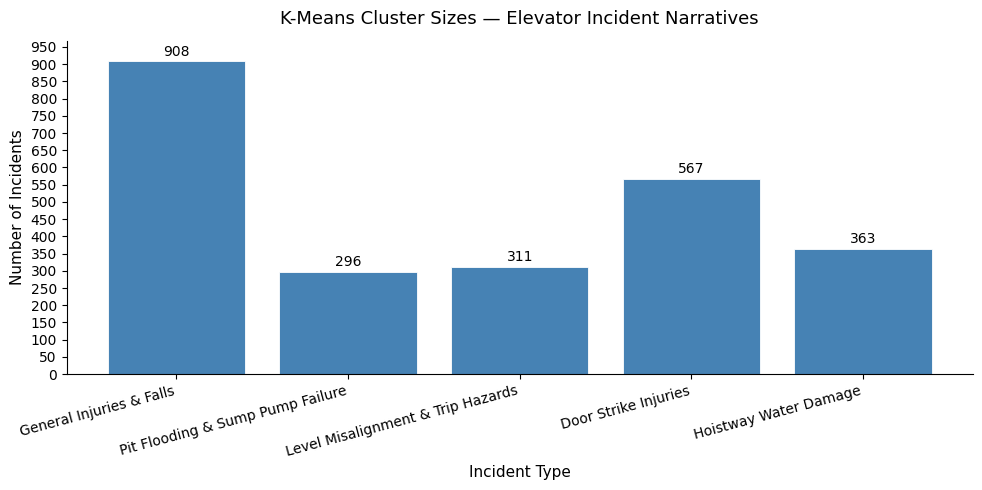

Saved → assets/incident_topic_distribution.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cluster_sizes = df["cluster"].value_counts().sort_index()
labels = [CLUSTER_NAMES[i] for i in cluster_sizes.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    labels,
    cluster_sizes.values,
    color="steelblue",
    edgecolor="white",
    linewidth=0.6
)

for bar, val in zip(bars, cluster_sizes.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        str(val),
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("K-Means Cluster Sizes — Elevator Incident Narratives", fontsize=13, pad=12)
ax.set_xlabel("Incident Type", fontsize=11)
ax.set_ylabel("Number of Incidents", fontsize=11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.set_ylim(0, cluster_sizes.max() + 60)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
plt.savefig("../assets/incident_topic_distribution.png", dpi=150)
plt.show()
print("Saved → assets/incident_topic_distribution.png")
